<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/Loss_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3714/3018134071.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Item_Weight'].fillna(train['Item_Weight'].mean(), inplace=True)
/tmp/ipykernel_3714/3018134071.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

========== KNN Regression Results ==========
K Value: 5
RMSE: 1229.25
MAE: 880.32
R2 Score: 0.4605


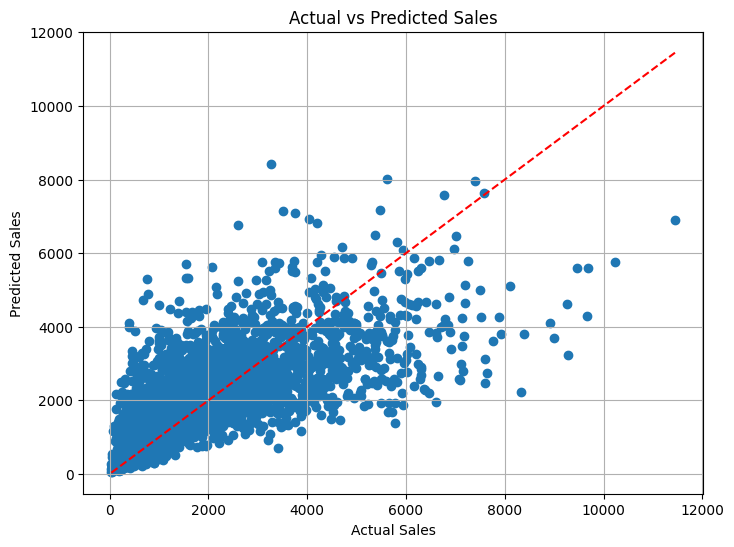

In [4]:
# Complete KNN Regression Code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Load Dataset
train_path = "https://raw.githubusercontent.com/PranavTadimeti/Regression-lab2/main/BigMart-train.csv"
train = pd.read_csv(train_path)

# Preprocessing
train['Item_Weight'].fillna(train['Item_Weight'].mean(), inplace=True)
train['Outlet_Size'].fillna(train['Outlet_Size'].mode()[0], inplace=True)

train.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)

# Convert categorical columns into numerical
train = pd.get_dummies(train)

# Features and Target
X = train.drop('Item_Outlet_Sales', axis=1)
y = train['Item_Outlet_Sales']

# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature Scaling
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Train KNN Model
k = 5

model = KNeighborsRegressor(n_neighbors=k)
model.fit(x_train, y_train)

# Predictions
y_pred = model.predict(x_test)

# Evaluation Metrics
rmse = sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("========== KNN Regression Results ==========")
print("K Value:", k)
print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))
print("R2 Score:", round(r2, 4))

# Actual vs Predicted Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.grid(True)
plt.show()